In [1]:
import torch
import pandas as pd

from pina.problem import SpatialProblem, TimeDependentProblem
from pina.operators import nabla, grad, div, curl, advection
from pina import Condition, Span, LabelTensor

output_data = pd.read_csv("data/q_si.csv", skiprows=None, header=None)
# output_data = output_data.values
output_data = output_data.apply(pd.to_numeric, errors='coerce').fillna(0).values
output_tensor = torch.from_numpy(output_data).float()
 
input_data = pd.read_csv("data/input_xyt.csv",skiprows = None , header = None)
# input_data = input_data.values
input_data = input_data.apply(pd.to_numeric, errors='coerce').fillna(0).values
input_tensor = torch.from_numpy(input_data).float()
 
input_tensor = LabelTensor(input_data,['x', 'y', 't'])
output_tensor = LabelTensor(output_data,['q', 'si'])

class QGE(SpatialProblem, TimeDependentProblem):

    output_variables = ['q', 'si']
    spatial_domain = Span({'x': [0, 1], 'y': [-1, 1]})
    temporal_domain = Span({'t': [0, 1]})
    
    def rand_choice_integer_Data(self):
        pass 
    
    def eq1(input_, output_):
        nu = 0.0022
        Re = 100 / nu
        
        #convective term
        si_curl = curl(output_.extract(['si']), input_, d = ['x', 'y'])
        convective_ = advection(output_.extract(['q']), input_, velocity_field = si_curl, d = ['x', 'y'])
        
        #diffusive term
        diffusive_ = nabla(output_.extract(['q']), input_, d = ['x', 'y'])   
        
        #transient term 
        du = grad(output_.extract(['q']), input_)
        transient_ = du.extract('dqdt')
        
        #forcing term
        force_ = torch.sin(torch.pi * input_.extract(['y']))
        
        return transient_ + convective_ - (1/Re) * diffusive_ - force_
    
    def eq2(input_, output_):
        r0 = 0.0036
        
        #second equation
        output = output_.extract(['q']) + r0 * nabla(output_.extract(['si']), input_, d = ['x', 'y']) - input_.extract(['y'])
        return output
        
    def continuity(input_, output_):
        si_curl = curl(output_.extract(['si']), input_, d = ['x', 'y'])
        return div(si_curl, input_, d = ['x', 'y'])

    def initial_si(input_, output_):
        value = 0.0
        return output_.extract(['si']) - value
    
    def zeta(input_, output_):
        value = input_.extract(['y'])
        return output_.extract(['q']) - value
    
    def si(input_, output_):
        si_expected = 0.0
        return output_.extract(['si']) - si_expected
        
    
    conditions = {
        't0': Condition(Span({'x': [0, 1], 'y': [-1, 1], 't' : 0}), [initial_si, zeta]),
        
        # 'upper': Condition(Span({'x':  [0,1], 'y': 1, 't': [0,1]}), [si, zeta]),
        # 'fixedWall1': Condition(Span({'x':  0, 'y': [-1,1], 't': [0,1]}), [si, zeta]),
        # 'fixedWall2': Condition(Span({'x':  1, 'y': [-1,1], 't': [0,1]}), [si, zeta]),
        # 'fixedWall3': Condition(Span({'x':  [0,1], 'y': -1, 't': [0,1]}), [si, zeta]),
        
        # 'D': Condition(Span({'x': [0, 1], 'y': [-1, 1], 't': [0, 1]}), [eq1, eq2]),
        'D':Condition(Span({'x': [0, 1], 'y': [-1, 1], 't': [0, 1]}), [eq1]),
        
        'E': Condition(input_points = input_tensor,output_points = output_tensor),
    }


In [3]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

def plot_with_existing_points(pinn, components=None, fixed_variables={}, method='contourf',
                              res=25, filename=None, **kwargs):
    """
    Modified plot function to use existing training/test data points (input and output points)
    instead of sampling new points.
    """
    if components is None:
        components = [pinn.problem.output_variables]
    print(components)
    try:
        # Iterate over conditions to find input and output points
        for condition_name in pinn.problem.conditions:
            condition = pinn.problem.conditions[condition_name]
            
            if hasattr(condition, 'output_points'):
                # Use input and output points directly
                pts = condition.input_points.to(dtype=pinn.dtype, device=pinn.device)
                pts.requires_grad_(True)
                pts.retain_grad()
                
                # Make predictions based on input points
                predicted_output = pinn.model(pts)
                
        if isinstance(components, str):
            predicted_output = predicted_output.extract(components)
        elif callable(components):
            predicted_output = components(predicted_output)

        # Convert output to numpy arrays
        predicted_output_array = predicted_output.detach().cpu().numpy()
        pts_array = pts.detach().cpu().numpy()
        
        # Remove points where coordinates are (0, 0, 0)
        non_zero_mask = ~((pts_array == 0).all(axis=1))
        pts_array = pts_array[non_zero_mask]
        predicted_output_array = predicted_output_array[non_zero_mask]

        # Print shapes for verification
        print(f"Filtered Predicted output array shape: {predicted_output_array.shape}")
        print(f"Filtered Points array shape: {pts_array.shape}")

        # Create DataFrames for the predictions and input points
        df_predicted_output = pd.DataFrame(predicted_output_array, columns=['Prediction'])
        df_pts = pd.DataFrame(pts_array, columns=[f'Variable_{i}' for i in range(pts_array.shape[1])])
        
        # Save to .csv files
        df_predicted_output.to_csv("plotting/predicted_output.csv", index=False)
        df_pts.to_csv("plotting/points.csv", index=False)
        
        # Optionally, save plot
        if filename:
            plt.title(f'Output {components} with parameter {fixed_variables}')
            plt.savefig(filename)
        else:
            plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")


In [4]:

from torch.nn import Softplus
from pina import PINN
from pina.model import FeedForward


#args
id_run = 0
save = False

qge_problem = QGE()
model = FeedForward(
    layers=[256, 128, 64, 32],
    output_variables=qge_problem.output_variables,
    input_variables=qge_problem.input_variables,
    # func=Softplus,
)
pinn = PINN(
    qge_problem,
    model,
    lr=0.01,
    error_norm='mse',
    regularizer=1e-8
    )

if save:
    pinn.span_pts(
            {'n': 25, 'mode': 'grid', 'variables': 't'},
            {'n': 10, 'mode': 'grid', 'variables': 'x'},
            {'n': 20, 'mode': 'grid', 'variables': 'y'},
            # locations=['t0', 'upper','fixedWall1','fixedWall2','fixedWall3', 'D'])
            locations=['D', 't0'])

    pinn.train(5000, 500)
    # pinn.train(1, 1)
    with open('qge_history_{}.txt'.format(id_run), 'w') as file_:
        for i, losses in pinn.history_loss.items():
            file_.write('{} {}\n'.format(i, sum(losses)))
    pinn.save_state('qge_files/pina_data_trial.qge')
else:
    # pinn.load_state('qge_files/pina_data_trial.qge')
    pinn.load_state('qge_results_good/pina_data_trial.qge')
    plot_with_existing_points(pinn, components='si')
    # plotter.plot_loss(pinn)


si
Filtered Predicted output array shape: (20200, 1)
Filtered Points array shape: (20200, 3)


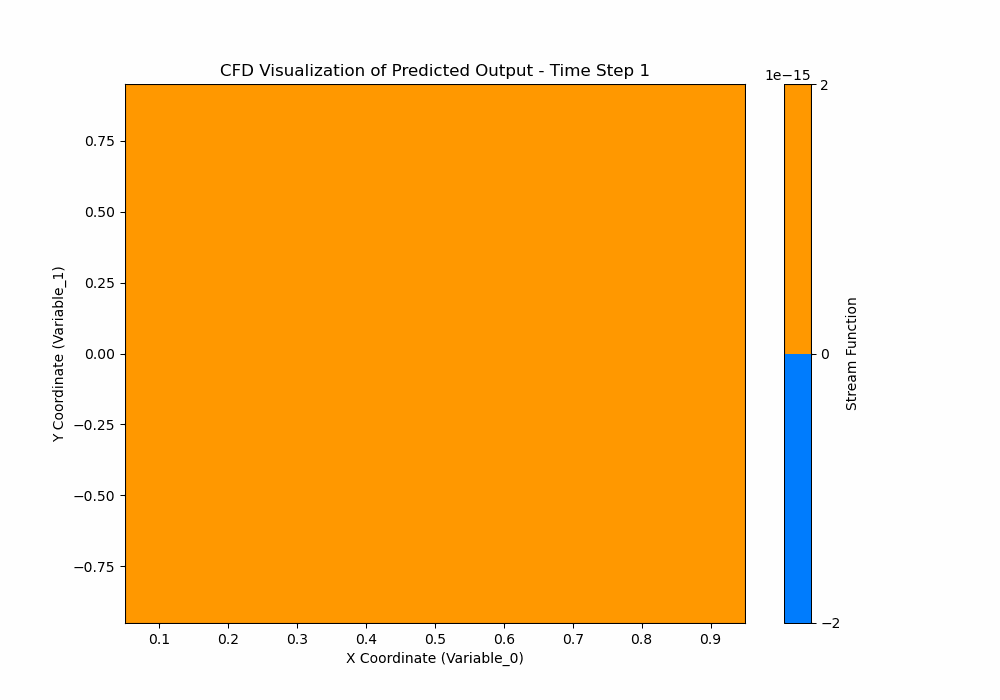

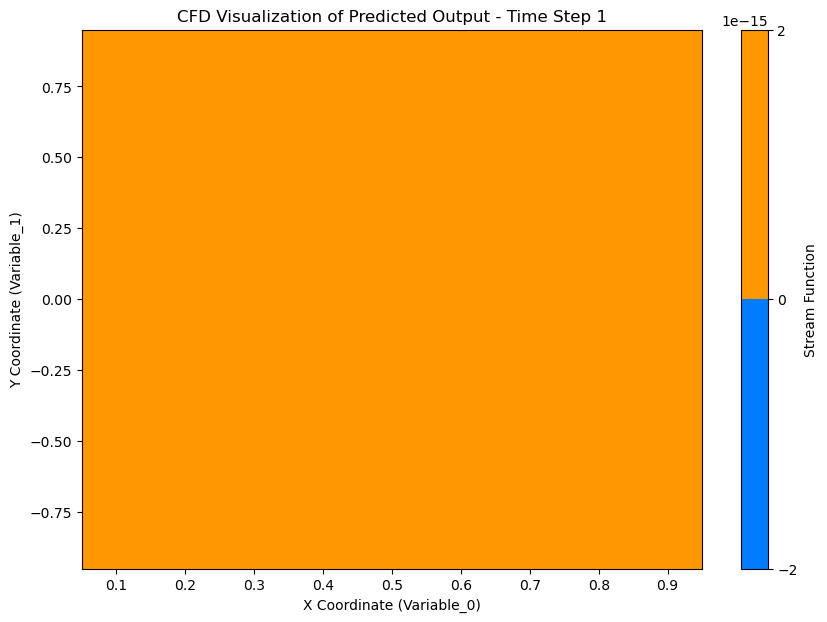

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation

path = os.getcwd()

# Load the data
points_df = pd.read_csv('openfoam_data/input_xyt.csv')
predicted_output_df = pd.read_csv('openfoam_data/q_si.csv')

predicted_output_df_psi = predicted_output_df.iloc[:, 1]

# Merge the dataframes if they are aligned by index
df = pd.concat([points_df, predicted_output_df_psi], axis=1)

# Number of time steps (assuming 101 time steps)
num_time_steps = 101
num_points_per_step = len(df) // num_time_steps

# Set up the figure and axis for the animation
fig, ax = plt.subplots(figsize=(10, 7))

# Create contour plot for the first frame to determine levels for consistent color bar
start_idx = 0
end_idx = num_points_per_step 
contour = ax.tricontourf(df['x'][start_idx:end_idx], 
                         df['y'][start_idx:end_idx], 
                         df['psi'][start_idx:end_idx], 
                         levels=100, cmap='jet')

# Add the color bar once, outside the update function
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Stream Function')

# Function to update each frame
def update(frame):
    ax.clear()  # Clear the previous frame
    start_idx = frame * num_points_per_step
    end_idx = (frame + 1) * num_points_per_step
    
    contour = ax.tricontourf(df['x'][start_idx:end_idx], 
                             df['y'][start_idx:end_idx], 
                             df['psi'][start_idx:end_idx], 
                             levels=100, cmap='jet')
    
    ax.set_title(f'CFD Visualization of Predicted Output - Time Step {frame+1}')
    ax.set_xlabel('X Coordinate (Variable_0)')
    ax.set_ylabel('Y Coordinate (Variable_1)')
    # The color bar remains static, so no need to add it again

# Create animation using FuncAnimation
anim = FuncAnimation(fig, update, frames=num_time_steps, repeat=False)

# Save the animation as a GIF
gif_path = os.path.join(path, 'psi_animation.gif')
anim.save(gif_path, writer='pillow', fps = 8)

# Display the GIF in Jupyter (or other environments)
from IPython.display import Image as IPImage
IPImage(filename=gif_path)


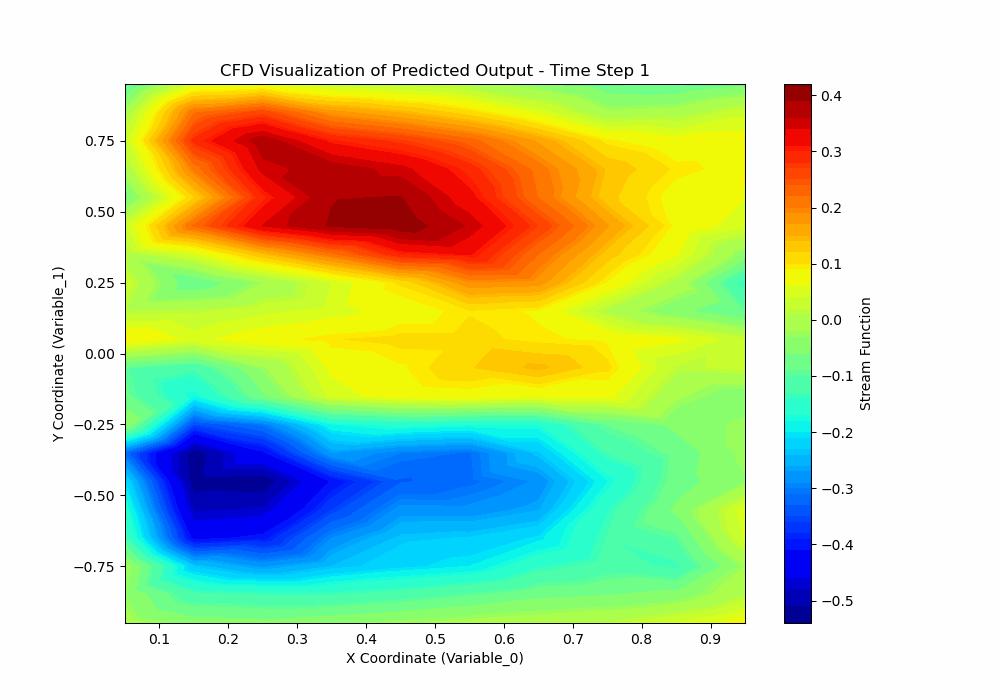

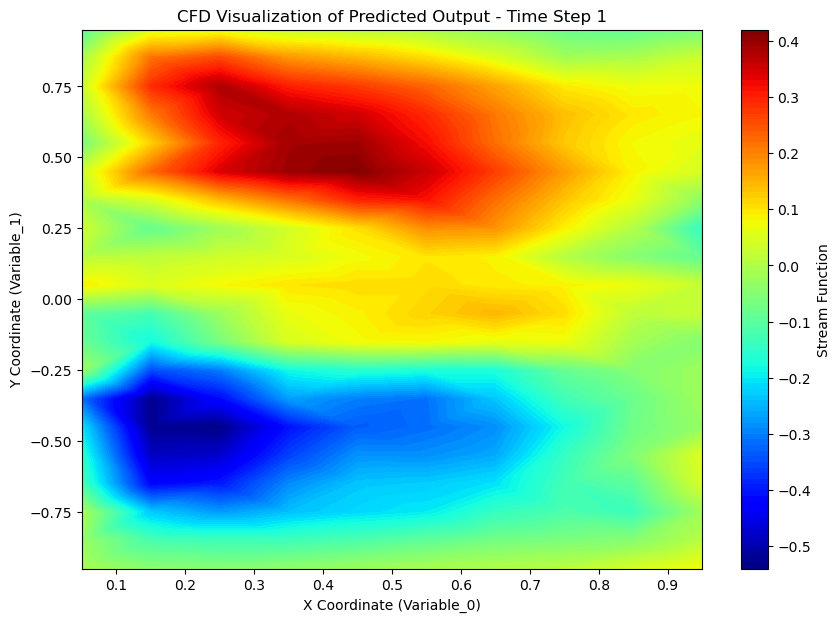

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation

path = 'gifs'
# Load the data
points_df = pd.read_csv('plotting/points.csv')
# predicted_output_df = pd.read_csv('openfoam_data/q_si.csv')
predicted_output_df = pd.read_csv('plotting/predicted_output.csv')

# Merge the dataframes if they are aligned by index
df = pd.concat([points_df, predicted_output_df], axis=1)

# Number of time steps (assuming 101 time steps)
num_time_steps = 101
num_points_per_step = len(df) // num_time_steps

# Set up the figure and axis for the animation
fig, ax = plt.subplots(figsize=(10, 7))

# Create contour plot for the first frame to determine levels for consistent color bar
start_idx = 0
end_idx = num_points_per_step
contour = ax.tricontourf(df['Variable_0'][start_idx:end_idx], 
                         df['Variable_1'][start_idx:end_idx], 
                         df['Prediction'][start_idx:end_idx], 
                         levels=100, cmap='jet')

# Add the color bar once, outside the update function
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Stream Function')

# Function to update each frame
def update(frame):
    ax.clear()  # Clear the previous frame
    start_idx = frame * num_points_per_step
    end_idx = (frame + 1) * num_points_per_step
    
    contour = ax.tricontourf(df['Variable_0'][start_idx:end_idx], 
                             df['Variable_1'][start_idx:end_idx], 
                             df['Prediction'][start_idx:end_idx], 
                             levels=100, cmap='jet')
    
    ax.set_title(f'CFD Visualization of Predicted Output - Time Step {frame+1}')
    ax.set_xlabel('X Coordinate (Variable_0)')
    ax.set_ylabel('Y Coordinate (Variable_1)')
    # The color bar remains static, so no need to add it again

# Create animation using FuncAnimation
anim = FuncAnimation(fig, update, frames=num_time_steps, repeat=False)

# Save the animation as a GIF
gif_path = os.path.join(path, 'cfd_evolution.gif')
anim.save(gif_path, writer='pillow')

# Display the GIF in Jupyter (or other environments)
from IPython.display import Image as IPImage
IPImage(filename=gif_path)


In [ ]:
# fix ten points, plot change of psi and q over time
# check is eq2 is minimising along with data loss
# increase learning rate and activation

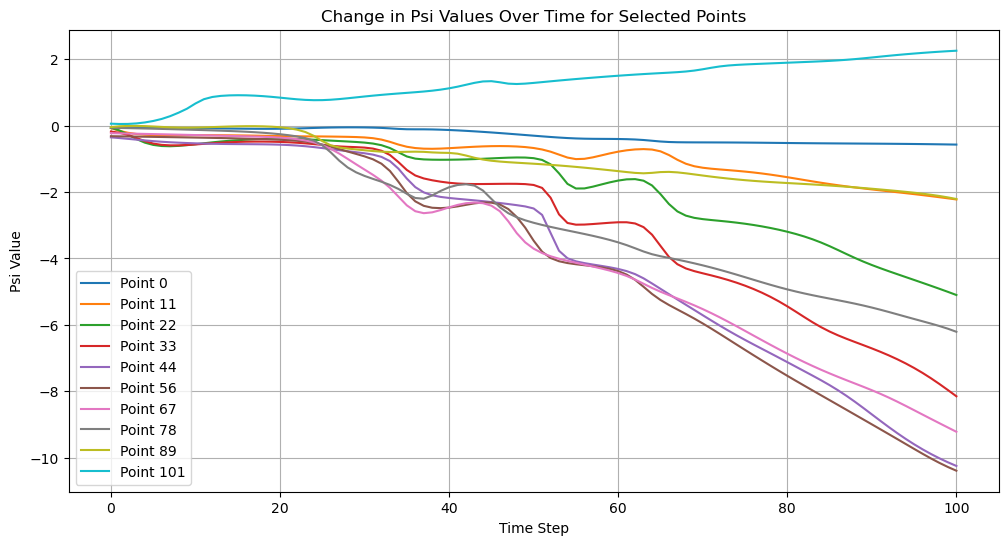

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
points_df = pd.read_csv('plotting/points.csv')
predicted_output_df = pd.read_csv('plotting/predicted_output.csv')

# Merge the dataframes
df = pd.concat([points_df, predicted_output_df], axis=1)

# Number of time steps (assuming 25 time steps)
num_time_steps = 101
num_points_per_step = len(df) // num_time_steps

# Choose 10 points to track across time steps (e.g., points 0, 1, 2, ..., 9)
# selected_points = list(range(10))
selected_points = np.linspace(0, 101, 10, dtype='int64').tolist();

# Initialize lists to store psi values over time for each selected point
psi_values_over_time = {point: [] for point in selected_points}

# Loop through each time step and extract psi values for the selected points
for t in range(num_time_steps):
    start_idx = t * num_points_per_step
    end_idx = (t + 1) * num_points_per_step
    time_step_df = df[start_idx:end_idx]

    for point in selected_points:
        psi_values_over_time[point].append(time_step_df['Prediction'].iloc[point])

# Plot the change in psi values over time for each selected point
plt.figure(figsize=(12, 6))
for point, psi_values in psi_values_over_time.items():
    plt.plot(range(num_time_steps), psi_values, label=f'Point {point}')
plt.title('Change in Psi Values Over Time for Selected Points')
plt.xlabel('Time Step')
plt.ylabel('Psi Value')
plt.legend()
plt.grid(True)
plt.show()


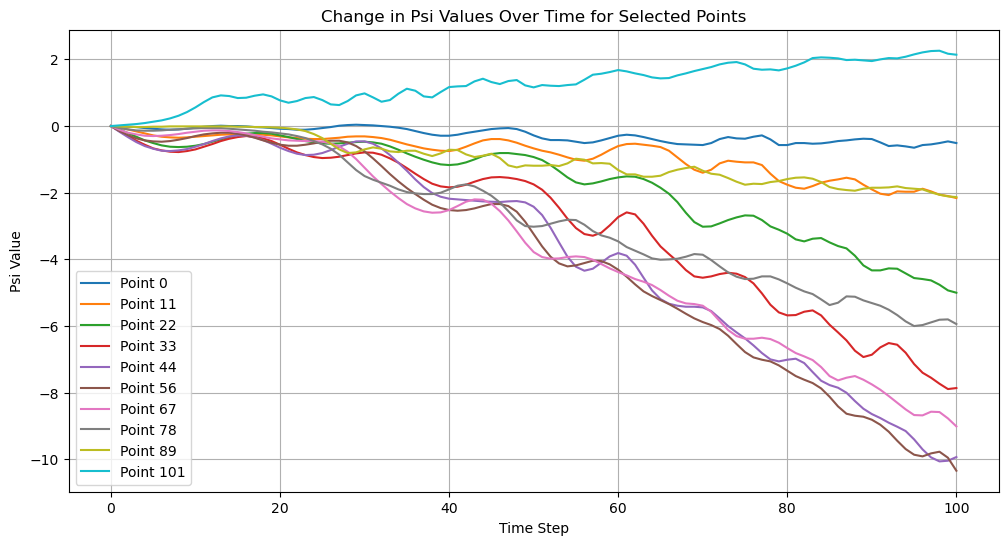

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
points_df = pd.read_csv('openfoam_data/input_xyt.csv')
predicted_output_df = pd.read_csv('openfoam_data/q_si.csv')
predicted_output_df_psi = predicted_output_df.iloc[:, 1]  # Assuming psi values are in the second column

# Merge the dataframes
df = pd.concat([points_df, predicted_output_df_psi.rename('psi')], axis=1)

# Number of time steps (assuming 100 time steps)
num_time_steps = 101
num_points_per_step = len(df) // num_time_steps

# Choose 10 points to track across time steps (e.g., points 0, 1, 2, ..., 9)
# selected_points = list(range(10))

# Initialize lists to store psi values over time for each selected point
psi_values_over_time = {point: [] for point in selected_points}

# Loop through each time step and extract psi values for the selected points
for t in range(num_time_steps):
    start_idx = t * num_points_per_step
    end_idx = (t + 1) * num_points_per_step
    time_step_df = df[start_idx:end_idx]

    for point in selected_points:
        psi_values_over_time[point].append(time_step_df['psi'].iloc[point])

# Plot the change in psi values over time for each selected point
plt.figure(figsize=(12, 6))
for point, psi_values in psi_values_over_time.items():
    plt.plot(range(num_time_steps), psi_values, label=f'Point {point}')
plt.title('Change in Psi Values Over Time for Selected Points')
plt.xlabel('Time Step')
plt.ylabel('Psi Value')
plt.legend()
plt.grid(True)
plt.show()
